# `evap_cool` — example usage

Semiclassical evaporative cooling for ideal quantum and classical gases, following

> Arvizu-Velázquez et al., *Semi-classical evaporative cooling: classical and quantum distributions*, arXiv (2026).

This notebook walks through the canonical workflow:

1. **Pick a trap** (`BoxTrap`, `QuadrupoleTrap`, `OscillatorTrap`).
2. **Set the initial state** $(N_0, T_0)$ and solve for $\mu_0$, $E_0$, $\Omega_0$ at thermodynamic equilibrium.
3. **Build a cut-off schedule** $Q_i$.
4. **Run the recursive evaporation** for bosons ($+1$), fermions ($-1$), and the classical Maxwell–Boltzmann limit.
5. **Visualise and persist** the runs.

The package layout is:

| Module | Purpose |
|---|---|
| `constants` | SI / eV physical constants |
| `polylog` | Modified polylogarithms $\tilde g_s$, $\bar g_s$, $g_s$ |
| `solvers` | Newton–Raphson root finders |
| `recurrences` | Term-list representation of the evaporation recurrences |
| `thermodynamics` | Trap classes + classical (MB) limit |
| `evaporation` | Simulation loops and result containers |
| `storage` | JSON persistence with schema versioning |
| `plots` | Matplotlib visualisations |


## Setup

Make sure the package is importable. From the repo root:

```bash
pip install -e .
```

The simulations rely on `mpmath` for arbitrary-precision polylogs, so they are
not blazing fast. The cell counts below (`n_steps = 1000`–`2000`) are tuned to
finish in a couple of minutes on a laptop. Scale up `n_steps` and `dQ` for
production runs.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from evap_cool import (
    # constants & traps
    ConstantsSI, ConstantsEV,
    BoxTrap, QuadrupoleTrap, OscillatorTrap,
    # initial-state and run helpers
    create_result_dict, create_mb_result_dict,
    build_cutoff_schedule,
    initialize_quantum_state, initialize_mb_state,
    run_quantum_evaporation, run_mb_evaporation,
    # I/O
    save_run, load_run, list_runs,
    # plots
    plot_combined_overview,
)

# Where saved runs live.
RUNS_DIR = "runs"
os.makedirs(RUNS_DIR, exist_ok=True)


## 1. Box trap — canonical end-to-end example

The 3D box has density of states $g(\epsilon) \propto \epsilon^{1/2}$, so the trap exponent is $s = 3/2$.
We use SI units throughout this section ($k_B$ in J/K, $\mu$, $E$ in J).


### 1.1 Define the trap and the initial $(N_0, T_0)$

In [2]:
# Box trap (SI by default).
trap_box = BoxTrap(V=6e-11)   # cavity volume [m^3]

# Initial thermodynamic state.
N0_box = 1.0e7
T0_box = 5.0e-5              # 50 µK

print(f"Trap : {trap_box.describe()}")
print(f"N0   = {N0_box:.3e}")
print(f"T0   = {T0_box:.3e} K")


Trap : {'name': 'box', 's': 1.5, 'kB': 1.38064852e-23, 'trap_class': 'BoxTrap', 'V': 6e-11, 'm': 3.817545e-26, 'h': 6.62607004e-34}
N0   = 1.000e+07
T0   = 5.000e-05 K


### 1.2 Solve for the initial chemical potential

For an ideal quantum gas, $(N_0, T_0)$ does not directly fix $\mu_0$ — we
have to invert the equation of state $N_{\text{eq}}(T_0,\mu_0) = N_0$ for
each statistics. The base class exposes `solve_alpha0` for exactly this:
it returns $\alpha_0 = \mu_0 / (k_B T_0)$.

Once $\alpha_0$ is known, $\mu_0 = \alpha_0 k_B T_0$, and the equilibrium
energy and grand potential follow directly from `equilibrium_E` and
`equilibrium_Omega`.


In [3]:
def solve_initial_quantum_state(trap, N0, T0, sign, **kw):
    #Return (mu0, E0, Omega0) consistent with (N0, T0) for the given statistics.
    alpha0 = trap.solve_alpha0(N0, T0, sign=sign, **kw)
    mu0    = alpha0 * trap.kB * T0
    E0     = float(trap.equilibrium_E(T0, mu0, sign).real)
    Omega0 = float(trap.equilibrium_Omega(T0, mu0, sign).real)
    return mu0, E0, Omega0


# Bosons (sign = +1)
mu0_b, E0_b, Omega0_b = solve_initial_quantum_state(trap_box, N0_box, T0_box, sign=+1)

# Fermions (sign = -1) — alpha can be positive, so widen the upper bracket.
mu0_f, E0_f, Omega0_f = solve_initial_quantum_state(
    trap_box, N0_box, T0_box, sign=-1, alpha_hi=20.0,
)

print("Bosons:")
print(f"  alpha0 = {mu0_b/(trap_box.kB*T0_box):.4f}   (must be < 0)")
print(f"  mu0    = {mu0_b:.3e} J")
print(f"  E0     = {E0_b:.3e} J")
print(f"  Omega0 = {Omega0_b:.3e} J")
print("Fermions:")
print(f"  alpha0 = {mu0_f/(trap_box.kB*T0_box):.4f}")
print(f"  mu0    = {mu0_f:.3e} J")
print(f"  E0     = {E0_f:.3e} J")
print(f"  Omega0 = {Omega0_f:.3e} J")


Bosons:
  alpha0 = -10.6907   (must be < 0)
  mu0    = -7.380e-27 J
  E0     = 1.035e-20 J
  Omega0 = -6.903e-21 J
Fermions:
  alpha0 = -10.6907
  mu0    = -7.380e-27 J
  E0     = 1.035e-20 J
  Omega0 = -6.903e-21 J


### 1.3 Build the cut-off schedule

The cut-off temperature $Q_i$ is decreased linearly. `build_cutoff_schedule(Q0, dQ, n_steps)`
returns $[Q_0 - dQ, Q_0 - 2 dQ, \ldots]$ — i.e. the schedule used by steps
$1 \ldots n_{\text{steps}}$ (the initial state already lives at index $0$).


In [4]:
Q0_box      = 5e-4           # initial cut-off [K] (η_c0 = Q0 / T0 = 10)
dQ_box      = 5e-8
n_steps_box = 20000

Q_schedule_box = build_cutoff_schedule(Q0=Q0_box, dQ=dQ_box, n_steps=n_steps_box)
print(f"Q0/T0 = {Q0_box / T0_box:.1f}    (eta_c at start)")
print(f"Q at last step: {Q_schedule_box[-1]:.3e} K")


Q0/T0 = 10.0    (eta_c at start)
Q at last step: -5.000e-04 K


### 1.4 Initialise the three result containers

We run three simulations on the same schedule: bosons, fermions, and the
classical (MB) limit. Each gets its own pre-populated dict.


In [5]:
# --- bosons ---
results_b = create_result_dict()
results_b["Q"] = Q_schedule_box
initialize_quantum_state(results_b, N0_box, T0_box, mu0_b, E0_b, Omega0_b)

# --- fermions ---
results_f = create_result_dict()
results_f["Q"] = Q_schedule_box
initialize_quantum_state(results_f, N0_box, T0_box, mu0_f, E0_f, Omega0_f)

# --- Maxwell–Boltzmann ---
results_mb = create_mb_result_dict()
results_mb["Q"] = Q_schedule_box
initialize_mb_state(results_mb, N0_box, T0_box)


### 1.5 Run the evaporation loops

For the quantum loops, `dT` and `dmu` are the initial perturbations passed
to the 2-variable Newton–Raphson rethermaliser. Scaling them to the
magnitudes of $T_0$ and $\mu_0$ tends to be robust.

The boson loop halts early if $\alpha = \mu/(k_BT)$ approaches $0$ from
below — the proxy for entering the Bose–Einstein-condensed regime, where
the semiclassical treatment breaks down.


In [6]:
# --- boson run ---
outcome_b = run_quantum_evaporation(
    results_b, trap_box, N0_box,
    n_steps=n_steps_box,
    dT=1e-20,
    dmu=1e-30,
    sign=+1,
)

# --- fermion run ---
outcome_f = run_quantum_evaporation(
    results_f, trap_box, N0_box,
    n_steps=n_steps_box,
    dT=1e-20,
    dmu=1e-30,
    sign=-1,
)

# --- classical (MB) run ---
outcome_mb = run_mb_evaporation(results_mb, trap_box, N0_box, n_steps=n_steps_box)

print(f"bosons  : {outcome_b.n_completed:>5}/{n_steps_box}  "
      f"halt={outcome_b.halt_reason}")
print(f"fermions: {outcome_f.n_completed:>5}/{n_steps_box}  "
      f"halt={outcome_f.halt_reason}")
print(f"MB      : {outcome_mb.n_completed:>5}/{n_steps_box}  "
      f"halt={outcome_mb.halt_reason}")


  [halt @ step 9998] ValueError: mu = 4.304861964147864e-31 >= 0 (crossed BEC boundary or NaN)
  [halt @ step 9998] TypeError: float() argument must be a string or a real number, not 'mpc'
  [halt @ step 9999] non-positive cut-off Q = 0.000e+00
bosons  :  9998/20000  halt=ValueError: mu = 4.304861964147864e-31 >= 0 (crossed BEC boundary or NaN)
fermions:  9998/20000  halt=TypeError: float() argument must be a string or a real number, not 'mpc'
MB      :  9999/20000  halt=non-positive cut-off Q = 0.000e+00


### 1.6 Visualise

`plot_combined_overview` overlays MB / bosons / fermions on three panels:
$T/T_0$ vs $Q$, $N/N_0$ vs $Q$, and $N/N_0$ vs $T/T_0$ (the cooling trajectory).


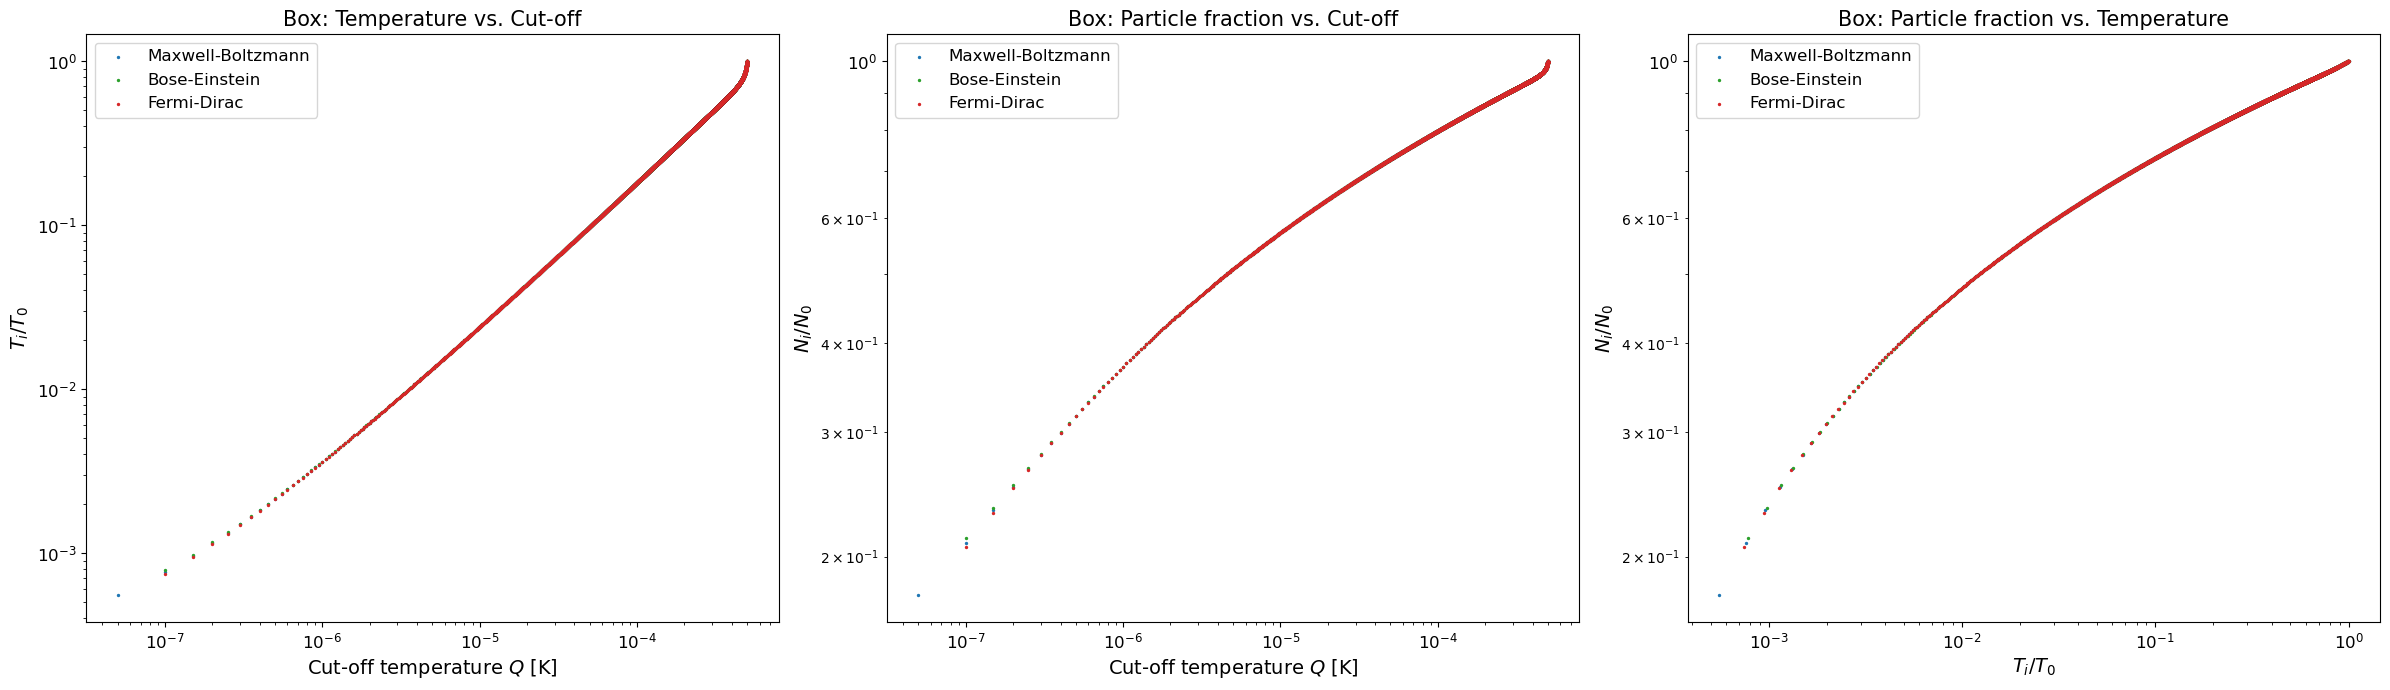

In [7]:
fig = plot_combined_overview(
    results_b, results_f, results_mb,
    trap_name="Box",
    n_b=outcome_b.n_completed,
    n_f=outcome_f.n_completed,
)
plt.show()


### 1.7 Persist runs to disk

`save_run` writes a versioned JSON payload (`SCHEMA_VERSION`-checked on load)
with the full results, the trap description, the parameters needed to
reproduce, and the run outcome. Safe to call on partial results after an
early halt — only what's in `results` is written.


In [8]:
common_params_box = dict(
    N0=N0_box, T0=T0_box,
    Q0=Q0_box, dQ=dQ_box, n_steps=n_steps_box,
)

save_run(
    results_b, f"{RUNS_DIR}/box_bosons.json",
    trap=trap_box,
    parameters={**common_params_box, "mu0": mu0_b, "E0": E0_b, "Omega0": Omega0_b, "sign": +1},
    outcome=outcome_b,
)
save_run(
    results_f, f"{RUNS_DIR}/box_fermions.json",
    trap=trap_box,
    parameters={**common_params_box, "mu0": mu0_f, "E0": E0_f, "Omega0": Omega0_f, "sign": -1},
    outcome=outcome_f,
)
save_run(
    results_mb, f"{RUNS_DIR}/box_mb.json",
    trap=trap_box,
    parameters={**common_params_box, "sign": 0},
    outcome=outcome_mb,                      # <-- now possible
)
print("Saved:", list_runs(RUNS_DIR))


Saved: [WindowsPath('runs/box_bosons.json'), WindowsPath('runs/box_fermions.json'), WindowsPath('runs/box_mb.json')]


## 2. Quadrupole trap

Linear potential $U(r) = \bar A\, r$ — density of states $g(\epsilon) \propto \epsilon^{7/2}$
so $s = 9/2$. `QuadrupoleTrap` defaults to **eV units** (energies in eV,
$k_B$ in eV/K), so $\mu$ and $E$ change scale but the workflow is identical.


  [halt @ step 9952] ValueError: mu = 1.7553938489300944e-12 >= 0 (crossed BEC boundary or NaN)
  [halt @ step 9947] TypeError: float() argument must be a string or a real number, not 'mpc'
  [halt @ step 9999] non-positive cut-off Q = 0.000e+00
bosons  :  9952/20000  halt=ValueError: mu = 1.7553938489300944e-12 >= 0 (crossed BEC boundary or NaN)
fermions:  9947/20000  halt=TypeError: float() argument must be a string or a real number, not 'mpc'
MB      :  9999/20000  halt=non-positive cut-off Q = 0.000e+00


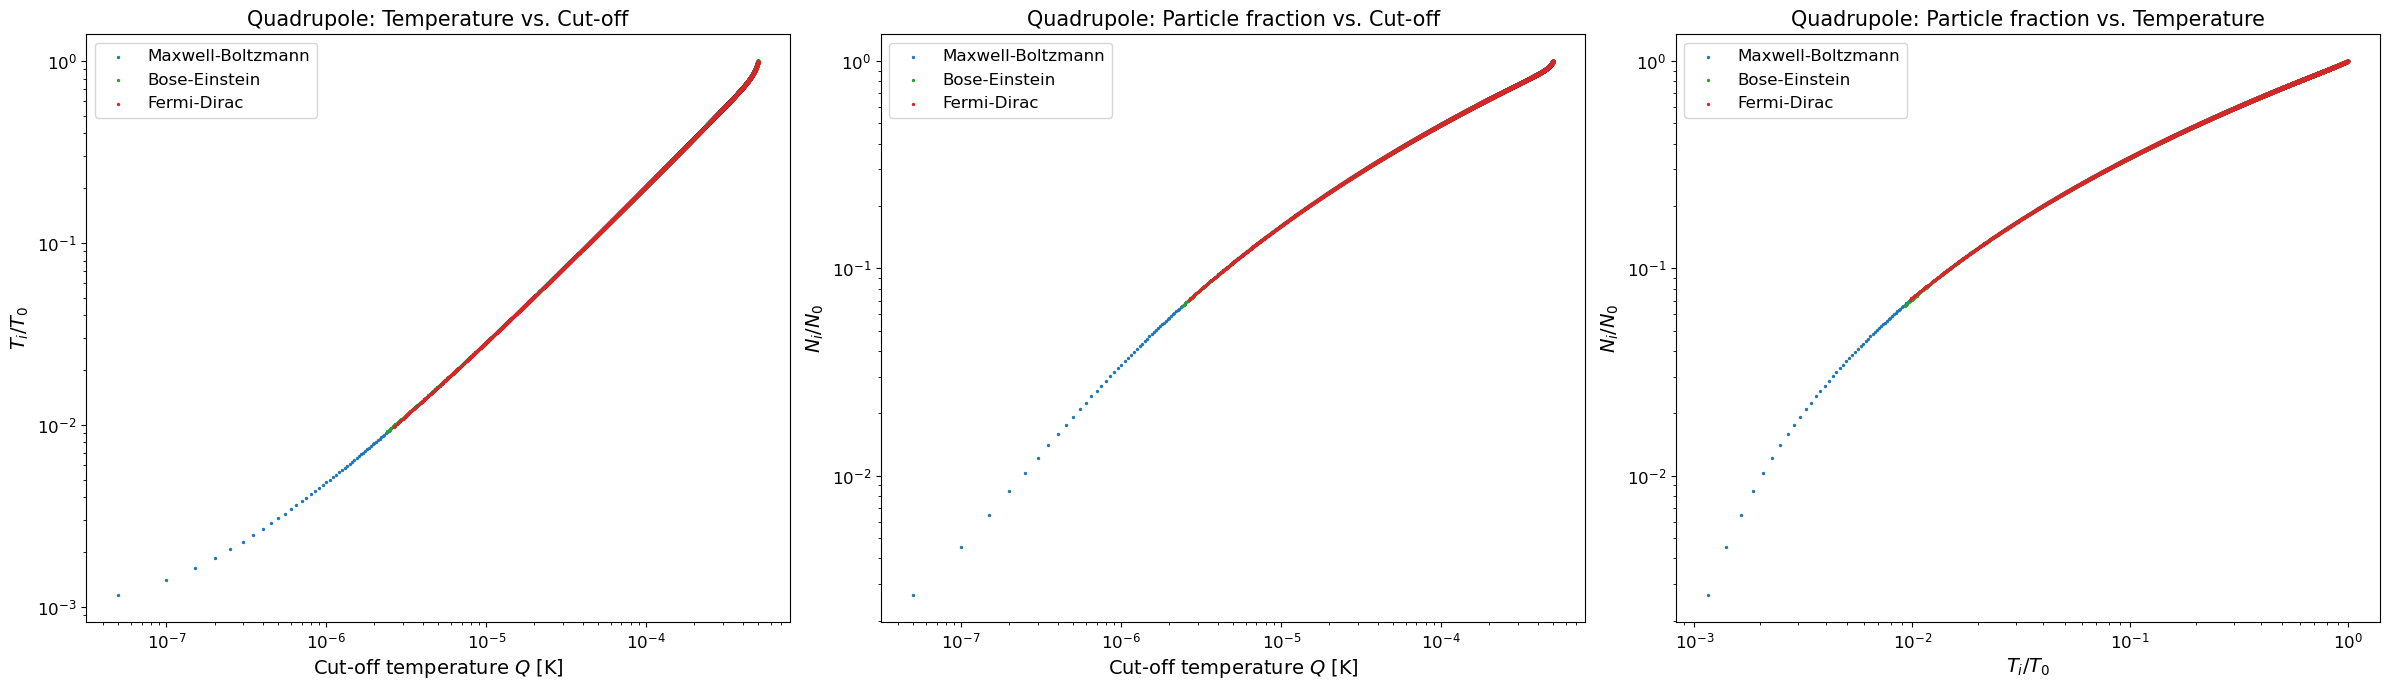

In [9]:
trap_quad = QuadrupoleTrap(A_bar=1e-15)   # eV / [length], illustrative
N0_q  = 1.0e7
T0_q  = 5.0e-5

# Initial state — same helper, different trap.
mu0_qb, E0_qb, Omega0_qb = solve_initial_quantum_state(trap_quad, N0_q, T0_q, sign=+1)
mu0_qf, E0_qf, Omega0_qf = solve_initial_quantum_state(trap_quad, N0_q, T0_q, sign=-1, alpha_hi=20.0)

# Schedule.
n_steps_q = 10000
Q0_q      = 5e-4           # initial cut-off [K] (η_c0 = Q0 / T0 = 10)
dQ_q      = 5e-8
Q_q = build_cutoff_schedule(Q0=Q0_q, dQ=dQ_q, n_steps=n_steps_q)

# Containers.
res_qb  = create_result_dict();   res_qb["Q"]  = Q_q
res_qf  = create_result_dict();   res_qf["Q"]  = Q_q
res_qmb = create_mb_result_dict(); res_qmb["Q"] = Q_q
initialize_quantum_state(res_qb, N0_q, T0_q, mu0_qb, E0_qb, Omega0_qb)
initialize_quantum_state(res_qf, N0_q, T0_q, mu0_qf, E0_qf, Omega0_qf)
initialize_mb_state(res_qmb, N0_q, T0_q)

# Runs.
out_qb = run_quantum_evaporation(res_qb, trap_quad, N0_q, n_steps_q,
                                 dT=T0_q*1e-12, dmu=abs(mu0_qb)*1e-12, sign=+1)
out_qf = run_quantum_evaporation(res_qf, trap_quad, N0_q, n_steps_q,
                                 dT=T0_q*1e-12, dmu=abs(mu0_qf)*1e-12, sign=-1)
out_qmb = run_mb_evaporation(res_qmb, trap_quad, N0_q, n_steps_q)

print(f"bosons  : {out_qb.n_completed:>5}/{n_steps_box}  "
      f"halt={out_qb.halt_reason}")
print(f"fermions: {out_qf.n_completed:>5}/{n_steps_box}  "
      f"halt={out_qf.halt_reason}")
print(f"MB      : {out_qmb.n_completed:>5}/{n_steps_box}  "
      f"halt={out_qmb.halt_reason}")

fig = plot_combined_overview(res_qb, res_qf, res_qmb,
                             trap_name="Quadrupole",
                             n_b=out_qb.n_completed, n_f=out_qf.n_completed)
plt.show()

In [ ]:
common_params_q = dict(
    N0=N0_q, T0=T0_q,
    Q0=Q0_q, dQ=dQ_q, n_steps=n_steps_q,
)

save_run(
    res_qb, f"{RUNS_DIR}/quad_bosons.json",
    trap=trap_quad,
    parameters={**common_params_q, "mu0": mu0_qb, "E0": E0_qb, "Omega0": Omega0_qb, "sign": +1},
    outcome=out_qb,
)
save_run(
    res_qf, f"{RUNS_DIR}/quad_fermions.json",
    trap=trap_quad,
    parameters={**common_params_q, "mu0": mu0_qf, "E0": E0_qf, "Omega0": Omega0_qf, "sign": -1},
    outcome=out_qf,
)
save_run(
    res_qmb, f"{RUNS_DIR}/quad_mb.json",
    trap=trap_quad,
    parameters={**common_params_q, "sign": 0},
    outcome=out_qmb,                      # <-- now possible
)
print("Saved:", list_runs(RUNS_DIR))

Saved: [WindowsPath('runs/box_bosons.json'), WindowsPath('runs/box_fermions.json'), WindowsPath('runs/box_mb.json'), WindowsPath('runs/quad_bosons.json'), WindowsPath('runs/quad_fermions.json')]


## 3. Harmonic oscillator trap

Isotropic 3D oscillator $U(r) = \tfrac{1}{2}m\omega^2 r^2$ — density of
states $g(\epsilon) \propto \epsilon^2$, so $s = 3$. Also defaults to eV units.


  [halt @ step 9931] ValueError: mu = 6.321169030126197e-13 >= 0 (crossed BEC boundary or NaN)
  [halt @ step 9983] TypeError: float() argument must be a string or a real number, not 'mpc'
  [halt @ step 9999] non-positive cut-off Q = 0.000e+00
bosons  :  9931/20000  halt=ValueError: mu = 6.321169030126197e-13 >= 0 (crossed BEC boundary or NaN)
fermions:  9983/20000  halt=TypeError: float() argument must be a string or a real number, not 'mpc'
MB      :  9999/20000  halt=non-positive cut-off Q = 0.000e+00


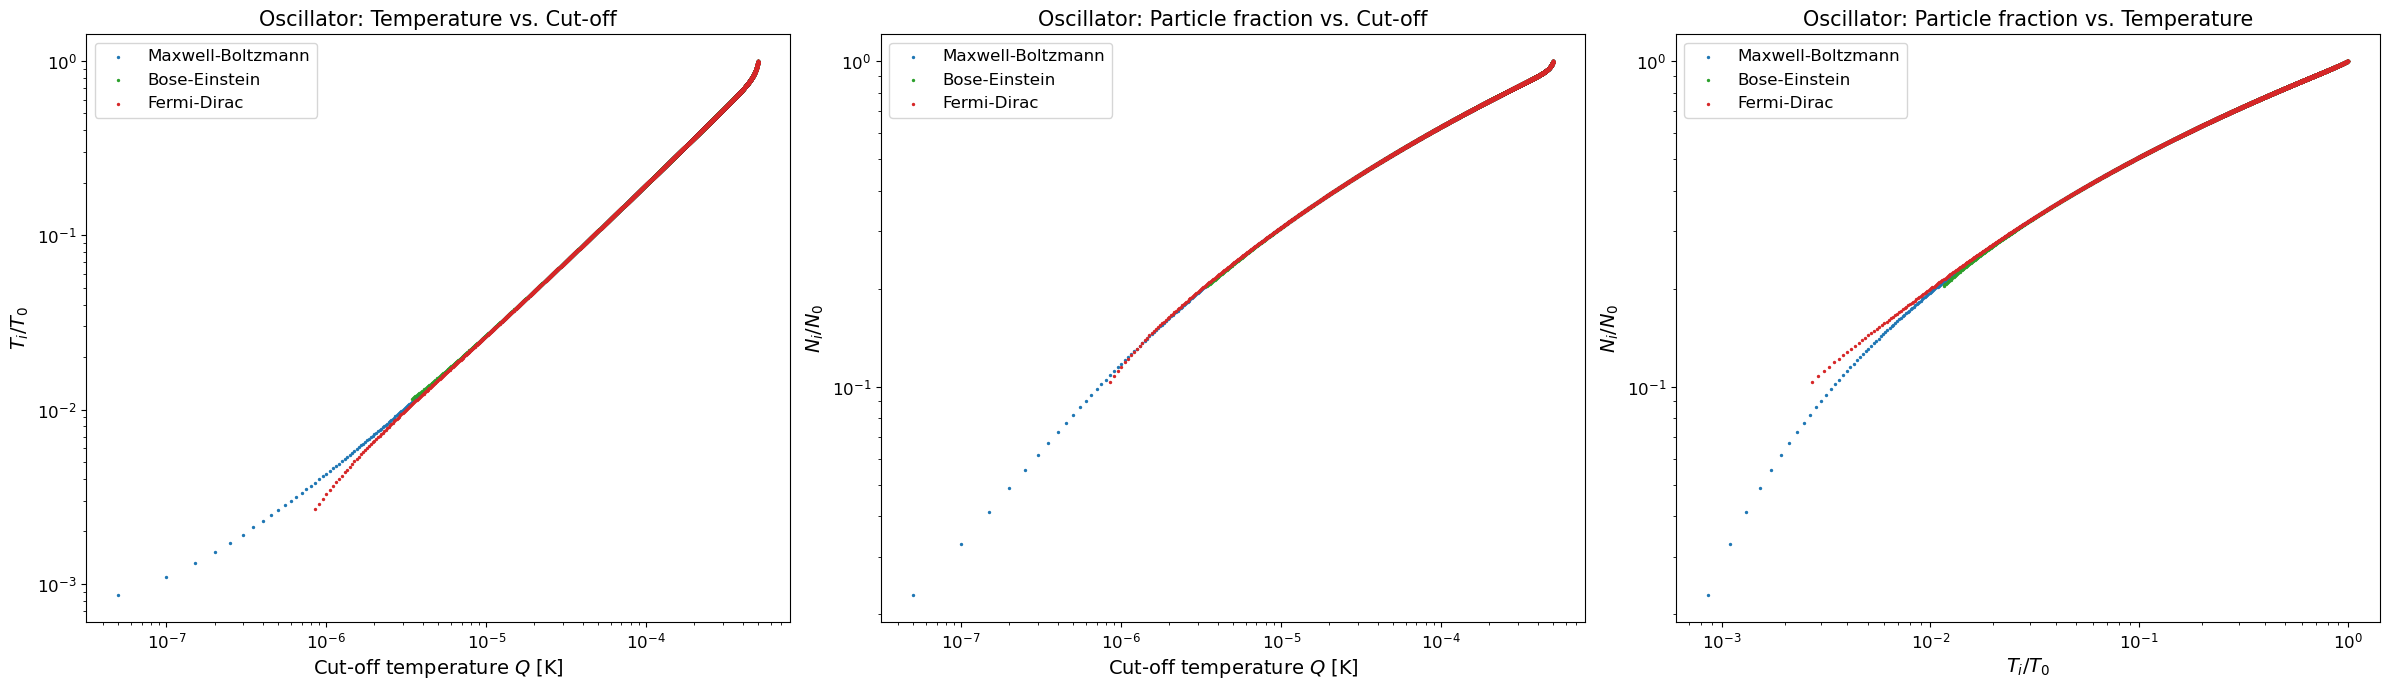

In [11]:
trap_osc = OscillatorTrap(omega=2 * np.pi * 100)  # 100 Hz trap
N0_o, T0_o = 1.0e7, 5.0e-5

mu0_ob, E0_ob, Omega0_ob = solve_initial_quantum_state(trap_osc, N0_o, T0_o, sign=+1)
mu0_of, E0_of, Omega0_of = solve_initial_quantum_state(trap_osc, N0_o, T0_o, sign=-1, alpha_hi=20.0)

n_steps_o = 10000
Q0_o      = 5e-4           # initial cut-off [K] (η_c0 = Q0 / T0 = 10)
dQ_o      = 5e-8
Q_o = build_cutoff_schedule(Q0=Q0_o, dQ=dQ_o, n_steps=n_steps_o)

res_ob  = create_result_dict();   res_ob["Q"]  = Q_o
res_of  = create_result_dict();   res_of["Q"]  = Q_o
res_omb = create_mb_result_dict(); res_omb["Q"] = Q_o
initialize_quantum_state(res_ob, N0_o, T0_o, mu0_ob, E0_ob, Omega0_ob)
initialize_quantum_state(res_of, N0_o, T0_o, mu0_of, E0_of, Omega0_of)
initialize_mb_state(res_omb, N0_o, T0_o)

out_ob = run_quantum_evaporation(res_ob, trap_osc, N0_o, n_steps_o,
                                 dT=T0_o*1e-12, dmu=abs(mu0_ob)*1e-12, sign=+1)
out_of = run_quantum_evaporation(res_of, trap_osc, N0_o, n_steps_o,
                                 dT=T0_o*1e-12, dmu=abs(mu0_of)*1e-12, sign=-1)
out_omb = run_mb_evaporation(res_omb, trap_osc, N0_o, n_steps_o)

print(f"bosons  : {out_ob.n_completed:>5}/{n_steps_box}  "
      f"halt={out_ob.halt_reason}")
print(f"fermions: {out_of.n_completed:>5}/{n_steps_box}  "
      f"halt={out_of.halt_reason}")
print(f"MB      : {out_omb.n_completed:>5}/{n_steps_box}  "
      f"halt={out_omb.halt_reason}")



fig = plot_combined_overview(res_ob, res_of, res_omb,
                             trap_name="Oscillator",
                             n_b=out_ob.n_completed, n_f=out_of.n_completed)
plt.show()

In [12]:
common_params_o = dict(
    N0=N0_o, T0=T0_o,
    Q0=Q0_o, dQ=dQ_o, n_steps=n_steps_o,
)

save_run(
    res_ob, f"{RUNS_DIR}/osc_bosons.json",
    trap=trap_osc,
    parameters={**common_params_o, "mu0": mu0_ob, "E0": E0_ob, "Omega0": Omega0_ob, "sign": +1},
    outcome=out_qb,
)
save_run(
    res_of, f"{RUNS_DIR}/osc_fermions.json",
    trap=trap_osc,
    parameters={**common_params_o, "mu0": mu0_of, "E0": E0_of, "Omega0": Omega0_of, "sign": -1},
    outcome=out_of,
)
save_run(
    res_omb, f"{RUNS_DIR}/osc_mb.json",
    trap=trap_osc,
    parameters={**common_params_o, "sign": 0},
    outcome=out_omb,                      # <-- now possible
)
print("Saved:", list_runs(RUNS_DIR))

Saved: [WindowsPath('runs/box_bosons.json'), WindowsPath('runs/box_fermions.json'), WindowsPath('runs/box_mb.json'), WindowsPath('runs/osc_bosons.json'), WindowsPath('runs/osc_fermions.json'), WindowsPath('runs/osc_mb.json'), WindowsPath('runs/quad_bosons.json'), WindowsPath('runs/quad_fermions.json')]


## 4. Loading runs back

`load_run` returns the full payload (`parameters`, `metadata`, `results`).
Schema version is checked — mismatched versions raise rather than silently
misinterpret. `list_runs` enumerates JSON files in a directory.


In [13]:
for path in list_runs(RUNS_DIR):
    payload  = load_run(path)
    meta     = payload["metadata"]
    params   = payload["parameters"]
    outcome  = meta.get("outcome", {})
    trap_md  = meta.get("trap", {})
    print(f"{path.name:30s}  trap={trap_md.get('name','?'):<10s}  "
          f"sign={params.get('sign'):>+2}  "
          f"steps={outcome.get('n_completed','?')}/{outcome.get('n_steps_requested','?')}")


box_bosons.json                 trap=box         sign=+1  steps=9998/20000
box_fermions.json               trap=box         sign=-1  steps=9998/20000
box_mb.json                     trap=quadrupole  sign=+0  steps=9999/10000
osc_bosons.json                 trap=oscillator  sign=+1  steps=9952/10000
osc_fermions.json               trap=oscillator  sign=-1  steps=9983/10000
osc_mb.json                     trap=oscillator  sign=+0  steps=9999/10000
quad_bosons.json                trap=quadrupole  sign=+1  steps=9952/10000
quad_fermions.json              trap=quadrupole  sign=-1  steps=9947/10000


## 5. Where to go from here

A few natural extensions worth flagging:

- **Finer cut-off schedules.** For paper-quality figures, push `n_steps` to
  $10^4$–$2\times10^4$ and shrink `dQ` accordingly. The cost is ~linear in
  `n_steps`.
- **Cross-geometry comparison.** Re-load the saved runs and overlay the
  bosonic cooling trajectories ($N/N_0$ vs $T/T_0$) for box, quadrupole
  and oscillator — a clean illustration of how the density-of-states
  exponent $s$ controls cooling efficiency.
- **Custom traps.** Subclass `Trap`, set `s` and `recurrences =
  pure_geometry_recurrences(s)`, and implement `equilibrium_N`,
  `equilibrium_E`, and `fused_jacobian`. The mixed geometries from
  sections 3.4 and 3.5 of the paper are the obvious candidates here.
- **Diagnostics.** When a run halts early, the recorded
  `metadata.outcome.halt_reason` plus the partial results dict are usually
  enough to localise the issue (BEC proximity vs NR breakdown vs sign
  flip on $\mu$).
